# Instalação das Bibliotecas e Configurações Iniciais

In [1]:
# ===================================================================='
# CÉLULA 1: INSTALAÇÃO E IMPORTAÇÕES
# ===================================================================='
!pip install yfinance pandas scikit-learn matplotlib xgboost ta joblib --user --quiet

import numpy as np
import pandas as pd
import yfinance as yf
from datetime import datetime, timedelta
import ta
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
import xgboost as xgb

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# Configuração dos Ativos

In [2]:
# ===================================================================='
# CÉLULA 2: CONFIGURAÇÃO DOS ATIVOS
# ===================================================================='
CONFIG_ATIVOS = {
    "VALE3.SA": {
        "setor": "Mineração",
        "fatores": ['^BVSP', 'CL=F', 'BRL=X', 'GC=F', 'SPY', 'IEF'],
        "nomes_fatores": ['Ibovespa', 'Petroleo', 'Cambio', 'Ouro', 'SP500', 'IEF_10Y']
    },
    "ITUB4.SA": {
        "setor": "Bancário",
        "fatores": ['^BVSP', 'BRL=X', 'IEF', '^VIX', 'SPY'],
        "nomes_fatores": ['Ibovespa', 'Cambio', 'IEF_10Y', 'VIX', 'SP500']
    },
    "LREN3.SA": {
        "setor": "Varejo",
        "fatores": ['^BVSP', 'BRL=X', 'SPY'],
        "nomes_fatores": ['Ibovespa', 'Cambio', 'SP500']
    }
}

# Funções de Coleta e Preparação dos Dados

In [3]:
# CÉLULA 3: FUNÇÕES DE DADOS
def coletar_dados(ticker, fatores, nomes_fatores, start, end):
    print(f"--- Coletando dados para {ticker} ---")
    todos_tickers = list(set([ticker] + fatores))
    dados = yf.download(todos_tickers, start=start, end=end, progress=False, auto_adjust=False)
    if dados.empty: return pd.DataFrame()
    df = pd.DataFrame(index=dados.index)
    df['Abertura'] = dados['Open'][ticker]
    df['Maxima'] = dados['High'][ticker]
    df['Minima'] = dados['Low'][ticker]
    df['Preco_Fechamento'] = dados['Close'][ticker]
    df['Volume'] = dados['Volume'][ticker]
    for fator, nome in zip(fatores, nomes_fatores):
        if fator in dados['Close'].columns: df[nome] = dados['Close'][fator]
        else: print(f"Aviso: Não foi possível baixar o fator '{nome}' ({fator}).")
    return df

def engenharia_fatores(df):
    print("--- Realizando engenharia de fatores ---")
    df['Retorno_1d'] = df['Preco_Fechamento'].pct_change()
    df['Retorno_Futuro'] = df['Preco_Fechamento'].pct_change().shift(-1)
    df['Momentum_5d'] = df['Preco_Fechamento'].pct_change(5)
    df['Volatilidade_10d'] = df['Retorno_1d'].rolling(window=10).std()
    df['RSI_14d'] = ta.momentum.RSIIndicator(close=df['Preco_Fechamento'], window=14).rsi()
    df['SMA_10_50_Ratio'] = ta.trend.SMAIndicator(df['Preco_Fechamento'], window=10).sma_indicator() / ta.trend.SMAIndicator(df['Preco_Fechamento'], window=50).sma_indicator()
    df.dropna(inplace=True)
    if df.empty:
        print("ERRO CRÍTICO: DataFrame ficou vazio.")
        return df
    df['Target_Compra'] = (df['Retorno_Futuro'] > 0.002).astype(int)
    return df

# Funções de Machine Learning 

In [4]:
# CÉLULA 4: FUNÇÕES DE MACHINE LEARNING
def otimizar_modelo(df, features, target):
    print("--- Otimizando modelo com GridSearchCV e TimeSeriesSplit ---")
    X = df[features]
    y = df[target]
    if X.empty: return None, None
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    tscv = TimeSeriesSplit(n_splits=3)
    param_grid_xgb = {"max_depth": [3, 5], "n_estimators": [100, 200], "learning_rate": [0.05, 0.1]}
    xgb_model = xgb.XGBClassifier(objective='binary:logistic', use_label_encoder=False, verbosity=0, eval_metric='logloss', random_state=123)
    gsearch_xgb = GridSearchCV(xgb_model, param_grid_xgb, cv=tscv, scoring='accuracy', n_jobs=-1)
    gsearch_xgb.fit(X_scaled, y)
    print(f"Melhores parâmetros encontrados: {gsearch_xgb.best_params_}")
    return gsearch_xgb.best_estimator_, scaler

def fazer_predicoes(modelo, scaler, df, features):
    X = df[features]
    X_scaled = scaler.transform(X)
    proba = modelo.predict_proba(X_scaled)[:, 1]
    return (proba > 0.55).astype(int), proba

# Funções de Simulação (Backtesting) e Gráficos

In [5]:
# CÉLULA 5: FUNÇÕES DE BACKTESTING E VISUALIZAÇÃO
def backtest_com_stops(df, sinais, capital_inicial=10000, stop_loss_pct=0.02, take_profit_pct=0.04):
    print("--- Executando backtest com Stop-Loss e Take-Profit ---")
    capital = capital_inicial
    posicao = 0
    capitais = []
    preco_compra = 0
    for i in range(len(df)):
        preco_atual = df['Preco_Fechamento'].iloc[i]
        if posicao == 1:
            retorno = (preco_atual - preco_compra) / preco_compra
            if retorno <= -stop_loss_pct or retorno >= take_profit_pct:
                capital *= (1 + retorno)
                posicao = 0
                preco_compra = 0
        if sinais[i] == 1 and posicao == 0:
            posicao = 1
            preco_compra = preco_atual
        capitais.append(capital)
    return capitais

def plotar_capital(df, capital_acumulado, ticker):
    df_plot = pd.DataFrame(index=df.index)
    df_plot['Capital'] = capital_acumulado
    df_plot['Benchmark'] = (df['Preco_Fechamento'] / df['Preco_Fechamento'].iloc[0]) * 10000
    plt.figure(figsize=(12, 7))
    plt.plot(df_plot.index, df_plot['Capital'], label='Capital da Estratégia', color='blue')
    plt.plot(df_plot.index, df_plot['Benchmark'], label='Benchmark (Buy & Hold)', color='gray', linestyle='--')
    plt.title(f'Desempenho da Estratégia para {ticker}', fontsize=16)
    plt.xlabel('Data')
    plt.ylabel('Capital (R$)')
    plt.legend()
    plt.grid(True)
    nome_arquivo_grafico = f'desempenho_{ticker}_evento_2024.png'
    plt.savefig(nome_arquivo_grafico)
    print(f"Gráfico de desempenho salvo como: {nome_arquivo_grafico}")
    plt.show()

# Main


================== INICIANDO ANÁLISE DE EVENTO PARA: VALE3.SA ==================
--- Coletando dados para VALE3.SA ---
--- Realizando engenharia de fatores ---
--- Divisão dos Dados ---
Período de Treino: 2019-09-17 a 2023-09-06
Período de Teste: 2024-08-08 a 2024-10-29
--- Otimizando modelo com GridSearchCV e TimeSeriesSplit ---
Melhores parâmetros encontrados: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
--- Executando backtest com Stop-Loss e Take-Profit ---
Gráfico de desempenho salvo como: desempenho_VALE3.SA_evento_2024.png


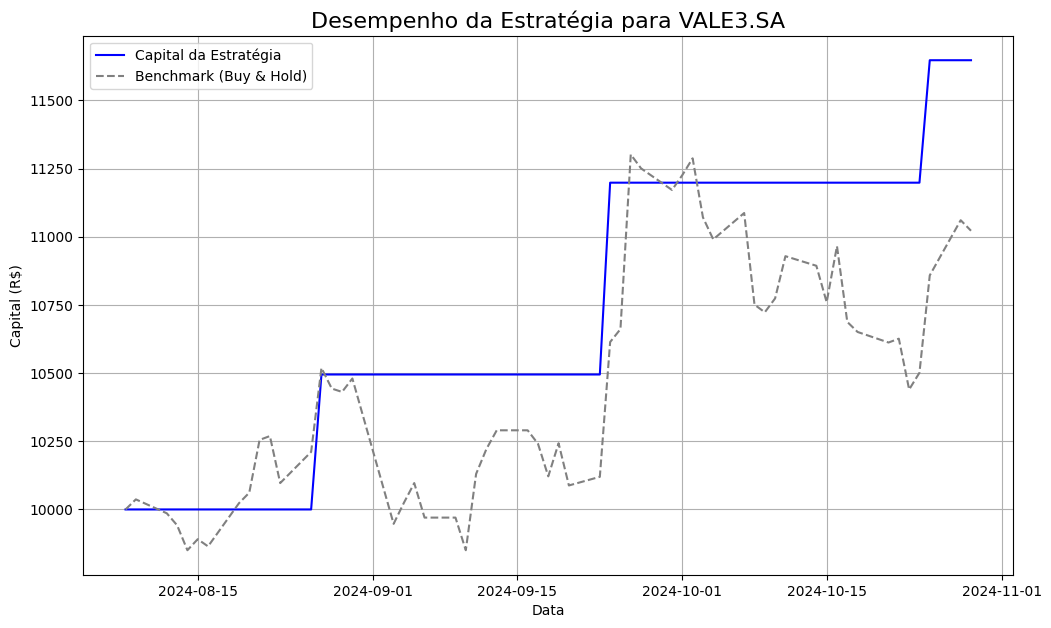


--- Relatório Final do Evento para VALE3.SA ---
Período de Teste (Crise): 01/05/2024 a 31/10/2024
Retorno da Estratégia: 16.47%
Retorno do Benchmark (Buy & Hold): 10.22%
Capital Final Estimado: R$ 11647.35
----------------------------------------

================== INICIANDO ANÁLISE DE EVENTO PARA: ITUB4.SA ==================
--- Coletando dados para ITUB4.SA ---
--- Realizando engenharia de fatores ---
--- Divisão dos Dados ---
Período de Treino: 2019-09-17 a 2023-09-06
Período de Teste: 2024-08-08 a 2024-10-29
--- Otimizando modelo com GridSearchCV e TimeSeriesSplit ---
Melhores parâmetros encontrados: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
--- Executando backtest com Stop-Loss e Take-Profit ---
Gráfico de desempenho salvo como: desempenho_ITUB4.SA_evento_2024.png


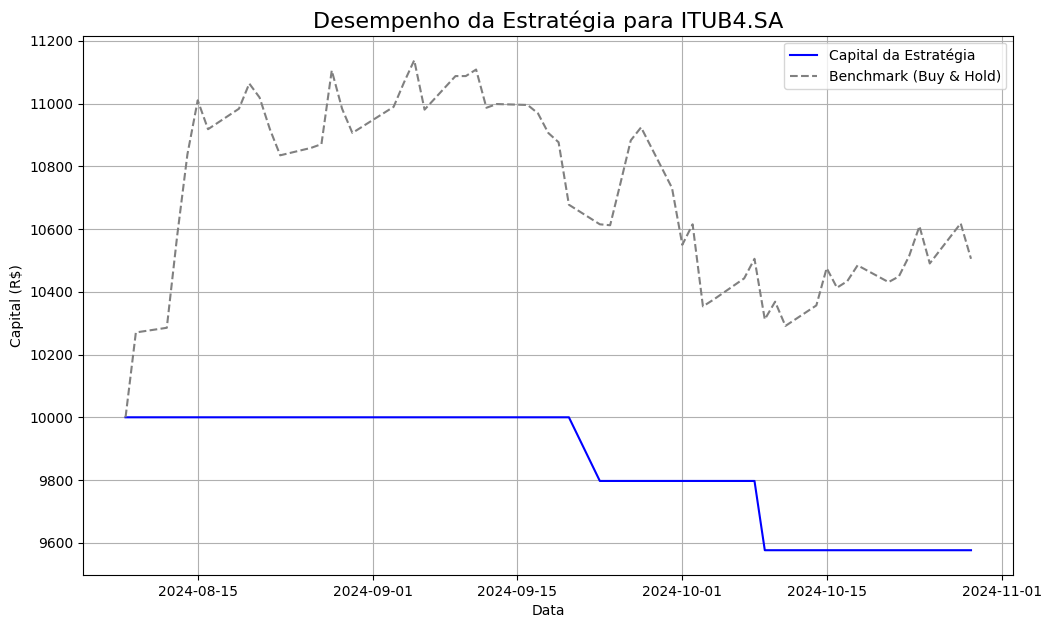


--- Relatório Final do Evento para ITUB4.SA ---
Período de Teste (Crise): 01/05/2024 a 31/10/2024
Retorno da Estratégia: -4.24%
Retorno do Benchmark (Buy & Hold): 5.05%
Capital Final Estimado: R$ 9576.26
----------------------------------------

================== INICIANDO ANÁLISE DE EVENTO PARA: LREN3.SA ==================
--- Coletando dados para LREN3.SA ---
--- Realizando engenharia de fatores ---
--- Divisão dos Dados ---
Período de Treino: 2019-09-17 a 2023-09-06
Período de Teste: 2024-08-08 a 2024-10-29
--- Otimizando modelo com GridSearchCV e TimeSeriesSplit ---
Melhores parâmetros encontrados: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
--- Executando backtest com Stop-Loss e Take-Profit ---
Gráfico de desempenho salvo como: desempenho_LREN3.SA_evento_2024.png


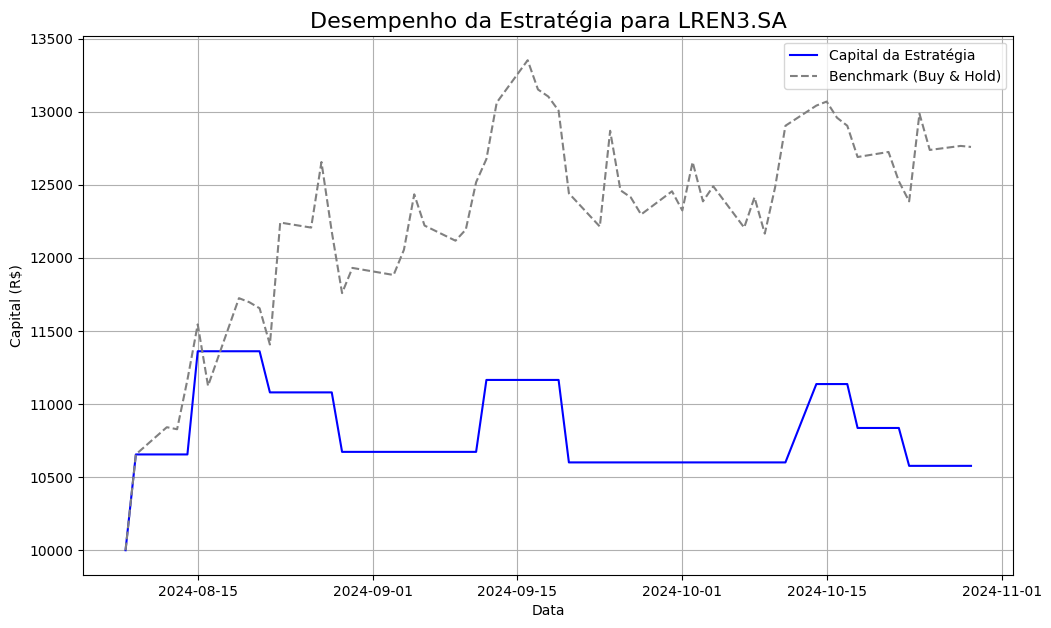


--- Relatório Final do Evento para LREN3.SA ---
Período de Teste (Crise): 01/05/2024 a 31/10/2024
Retorno da Estratégia: 5.77%
Retorno do Benchmark (Buy & Hold): 27.59%
Capital Final Estimado: R$ 10577.12
----------------------------------------


In [6]:
# ===================================================================='
# CÉLULA 6: BLOCO DE EXECUÇÃO - ESTUDO DE EVENTO (ENCHENTES 2024)
# ===================================================================='
if __name__ == "__main__":
    
    # --- Painel de Controle do Backtest de Evento ---
    # Data final para os dados de TREINO. O modelo só "conhecerá" o mundo até esta data.
    DATA_FIM_TREINO = datetime(2024, 4, 30)
    
    # Data de início do TESTE, simulando o período da crise.
    DATA_INICIO_TESTE = datetime(2024, 5, 1)
    
    # Data final do nosso período de análise de teste.
    DATA_FIM_TESTE = datetime(2024, 10, 31)
    
    # A coleta de dados começa 5 anos ANTES do fim do treino.
    start_date_coleta = DATA_FIM_TREINO - timedelta(days=5*365)
    
    # ---------------------------------------------------

    for ativo, conf in CONFIG_ATIVOS.items():
        print("\n" + "="*80)
        print(f" INICIANDO ANÁLISE DE EVENTO PARA: {ativo} ".center(80, "="))
        print("="*80)
        
        # 1. Coleta e Engenharia de Fatores (no período completo)
        df_completo = coletar_dados(ativo, conf['fatores'], conf['nomes_fatores'], start_date_coleta, DATA_FIM_TESTE)
        if df_completo.empty: continue
        
        df_eng_completo = engenharia_fatores(df_completo)
        if df_eng_completo.empty: continue
            
        # 2. Divisão RIGOROSA entre Treino e Teste
        df_treino = df_eng_completo[df_eng_completo.index.date < DATA_FIM_TREINO.date()]
        df_teste = df_eng_completo[df_eng_completo.index.date >= DATA_INICIO_TESTE.date()]
        
        print(f"--- Divisão dos Dados ---")
        print(f"Período de Treino: {df_treino.index.min().strftime('%Y-%m-%d')} a {df_treino.index.max().strftime('%Y-%m-%d')}")
        print(f"Período de Teste: {df_teste.index.min().strftime('%Y-%m-%d')} a {df_teste.index.max().strftime('%Y-%m-%d')}")

        if df_treino.empty or df_teste.empty:
            print("Erro: Conjunto de treino ou teste ficou vazio. Verifique as datas.")
            continue
            
        # 3. Otimização do Modelo (APENAS com dados de treino)
        features = [col for col in df_treino.columns if col not in ['Retorno_Futuro', 'Target_Compra', 'Abertura', 'Maxima', 'Minima', 'Preco_Fechamento', 'Volume']]
        modelo, scaler = otimizar_modelo(df_treino, features, 'Target_Compra')
        if modelo is None: continue

        # 4. Predição (APENAS nos dados de teste, que o modelo nunca viu)
        sinais, proba = fazer_predicoes(modelo, scaler, df_teste, features)
        
        # 5. Backtest (APENAS no período da crise)
        capital_acumulado = backtest_com_stops(df_teste, sinais)
        
        # 6. Visualização e Relatório
        plotar_capital(df_teste, capital_acumulado, ativo)

        retorno_final = (capital_acumulado[-1] / capital_acumulado[0] - 1) * 100
        retorno_benchmark = (df_teste['Preco_Fechamento'].iloc[-1] / df_teste['Preco_Fechamento'].iloc[0] - 1) * 100

        print(f"\n--- Relatório Final do Evento para {ativo} ---")
        print(f"Período de Teste (Crise): {DATA_INICIO_TESTE.strftime('%d/%m/%Y')} a {DATA_FIM_TESTE.strftime('%d/%m/%Y')}")
        print(f"Retorno da Estratégia: {retorno_final:.2f}%")
        print(f"Retorno do Benchmark (Buy & Hold): {retorno_benchmark:.2f}%")
        print(f"Capital Final Estimado: R$ {capital_acumulado[-1]:.2f}")
        print("-" * 40)


========= EXECUTANDO CENÁRIO: 'Crise COVID-19' PARA O ATIVO: VALE3.SA ==========
--- Coletando dados para VALE3.SA de 2018-01-01 a 2020-12-31 ---
--- Realizando engenharia de fatores ---
--- Otimizando hiperparâmetros do XGBoost... ---


C:\Users\jgsei\AppData\Local\Temp\ipykernel_23656\625477148.py:59: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Retorno_1d'] = df['Preco_Fechamento'].pct_change()
C:\Users\jgsei\AppData\Local\Temp\ipykernel_23656\625477148.py:61: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Momentum_5d'] = df['Preco_Fechamento'].pct_change(5)


Melhores parâmetros: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
--- Otimizando o limiar de decisão... ---
ERRO: Conjunto de validação vazio.
--- Executando backtest final ---

----------------------------------------
RESULTADO FINAL: VALE3.SA | Cenário: Crise COVID-19
Período de Teste: 2020-08-20 a 2020-09-04
Lucro/Perda da Estratégia IA: R$ 73.60
Lucro/Perda do Benchmark (Buy & Hold): R$ -39.08
----------------------------------------



C:\Users\jgsei\AppData\Local\Temp\ipykernel_23656\625477148.py:125: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_teste['Sinal_IA'] = sinais
C:\Users\jgsei\AppData\Local\Temp\ipykernel_23656\625477148.py:128: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_teste['Retorno_Estrategia'] = df_teste['Retorno_Futuro'] * df_teste['Sinal_IA']
C:\Users\jgsei\AppData\Local\Temp\ipykernel_23656\625477148.py:129: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .

Gráfico salvo como 'resultado_VALE3.SA_Crise_COVID-19.png'


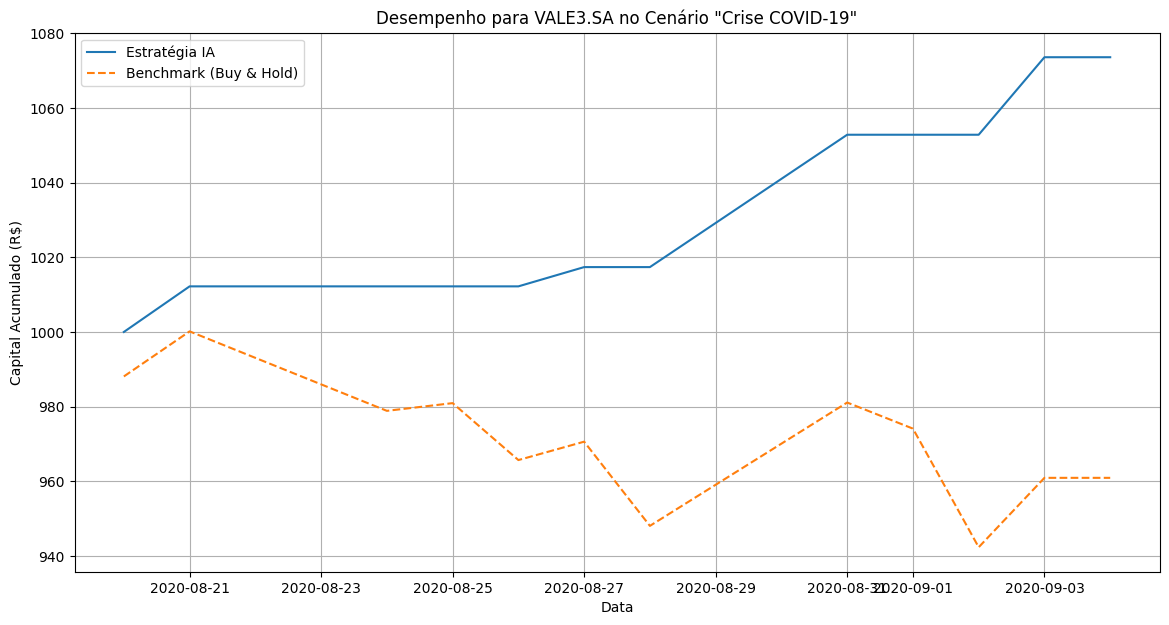


========= EXECUTANDO CENÁRIO: 'Crise COVID-19' PARA O ATIVO: ITUB4.SA ==========
--- Coletando dados para ITUB4.SA de 2018-01-01 a 2020-12-31 ---
--- Realizando engenharia de fatores ---
--- Otimizando hiperparâmetros do XGBoost... ---
Melhores parâmetros: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
--- Otimizando o limiar de decisão... ---
ERRO: Conjunto de validação vazio.
--- Executando backtest final ---

----------------------------------------
RESULTADO FINAL: ITUB4.SA | Cenário: Crise COVID-19
Período de Teste: 2020-08-20 a 2020-09-04
Lucro/Perda da Estratégia IA: R$ 53.09
Lucro/Perda do Benchmark (Buy & Hold): R$ 35.49
----------------------------------------



C:\Users\jgsei\AppData\Local\Temp\ipykernel_23656\625477148.py:59: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Retorno_1d'] = df['Preco_Fechamento'].pct_change()
C:\Users\jgsei\AppData\Local\Temp\ipykernel_23656\625477148.py:61: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Momentum_5d'] = df['Preco_Fechamento'].pct_change(5)
C:\Users\jgsei\AppData\Local\Temp\ipykernel_23656\625477148.py:125: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://p

Gráfico salvo como 'resultado_ITUB4.SA_Crise_COVID-19.png'


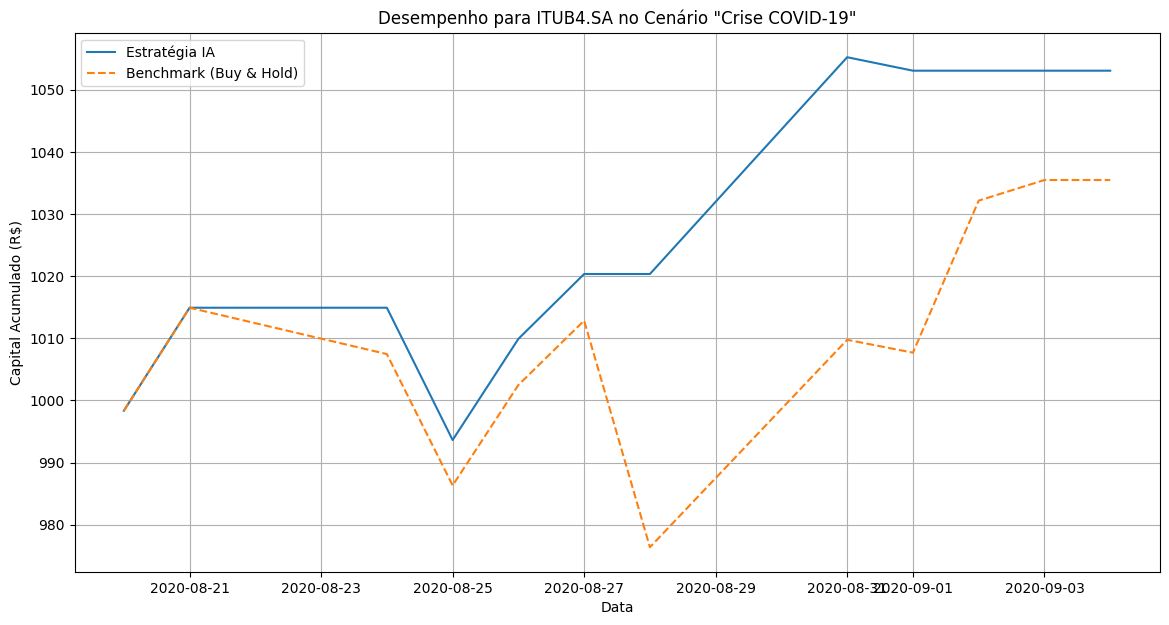


== EXECUTANDO CENÁRIO: 'Mercado de Alta Pós-Pandemia' PARA O ATIVO: VALE3.SA ===
--- Coletando dados para VALE3.SA de 2019-01-01 a 2021-12-31 ---
--- Realizando engenharia de fatores ---
--- Otimizando hiperparâmetros do XGBoost... ---
Melhores parâmetros: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
--- Otimizando o limiar de decisão... ---
ERRO: Conjunto de validação vazio.
--- Executando backtest final ---
ERRO: Conjunto de teste vazio. Backtest cancelado.

== EXECUTANDO CENÁRIO: 'Mercado de Alta Pós-Pandemia' PARA O ATIVO: ITUB4.SA ===
--- Coletando dados para ITUB4.SA de 2019-01-01 a 2021-12-31 ---


C:\Users\jgsei\AppData\Local\Temp\ipykernel_23656\625477148.py:59: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Retorno_1d'] = df['Preco_Fechamento'].pct_change()
C:\Users\jgsei\AppData\Local\Temp\ipykernel_23656\625477148.py:61: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Momentum_5d'] = df['Preco_Fechamento'].pct_change(5)


--- Realizando engenharia de fatores ---
--- Otimizando hiperparâmetros do XGBoost... ---
Melhores parâmetros: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
--- Otimizando o limiar de decisão... ---
ERRO: Conjunto de validação vazio.
--- Executando backtest final ---
ERRO: Conjunto de teste vazio. Backtest cancelado.

 EXECUTANDO CENÁRIO: 'Mercado Desafiador (Juros Altos)' PARA O ATIVO: VALE3.SA =
--- Coletando dados para VALE3.SA de 2020-01-01 a 2022-12-31 ---


C:\Users\jgsei\AppData\Local\Temp\ipykernel_23656\625477148.py:59: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Retorno_1d'] = df['Preco_Fechamento'].pct_change()
C:\Users\jgsei\AppData\Local\Temp\ipykernel_23656\625477148.py:61: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Momentum_5d'] = df['Preco_Fechamento'].pct_change(5)


--- Realizando engenharia de fatores ---
--- Otimizando hiperparâmetros do XGBoost... ---
Melhores parâmetros: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
--- Otimizando o limiar de decisão... ---
ERRO: Conjunto de validação vazio.
--- Executando backtest final ---

----------------------------------------
RESULTADO FINAL: VALE3.SA | Cenário: Mercado Desafiador (Juros Altos)
Período de Teste: 2022-08-25 a 2022-09-06
Lucro/Perda da Estratégia IA: R$ 3.85
Lucro/Perda do Benchmark (Buy & Hold): R$ -58.47
----------------------------------------



C:\Users\jgsei\AppData\Local\Temp\ipykernel_23656\625477148.py:59: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Retorno_1d'] = df['Preco_Fechamento'].pct_change()
C:\Users\jgsei\AppData\Local\Temp\ipykernel_23656\625477148.py:61: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Momentum_5d'] = df['Preco_Fechamento'].pct_change(5)
C:\Users\jgsei\AppData\Local\Temp\ipykernel_23656\625477148.py:125: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://p

Gráfico salvo como 'resultado_VALE3.SA_Mercado_Desafiador_(Juros_Altos).png'


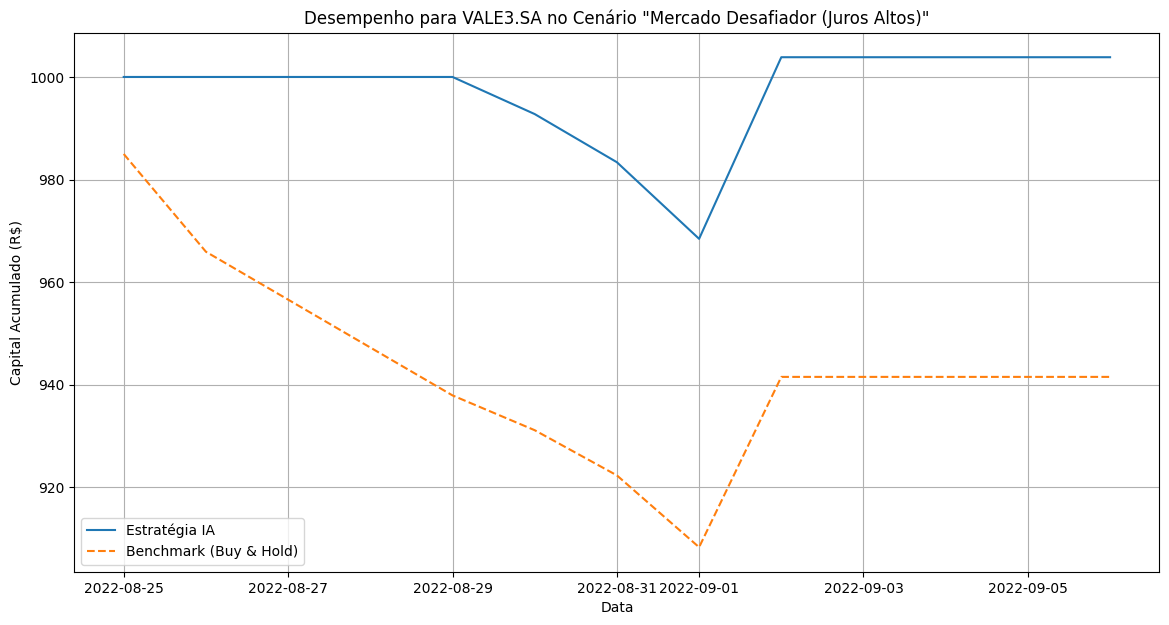


 EXECUTANDO CENÁRIO: 'Mercado Desafiador (Juros Altos)' PARA O ATIVO: ITUB4.SA =
--- Coletando dados para ITUB4.SA de 2020-01-01 a 2022-12-31 ---
--- Realizando engenharia de fatores ---
--- Otimizando hiperparâmetros do XGBoost... ---
Melhores parâmetros: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
--- Otimizando o limiar de decisão... ---
ERRO: Conjunto de validação vazio.
--- Executando backtest final ---

----------------------------------------
RESULTADO FINAL: ITUB4.SA | Cenário: Mercado Desafiador (Juros Altos)
Período de Teste: 2022-08-25 a 2022-09-06
Lucro/Perda da Estratégia IA: R$ 0.00
Lucro/Perda do Benchmark (Buy & Hold): R$ 5.53
----------------------------------------



C:\Users\jgsei\AppData\Local\Temp\ipykernel_23656\625477148.py:59: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Retorno_1d'] = df['Preco_Fechamento'].pct_change()
C:\Users\jgsei\AppData\Local\Temp\ipykernel_23656\625477148.py:61: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Momentum_5d'] = df['Preco_Fechamento'].pct_change(5)
C:\Users\jgsei\AppData\Local\Temp\ipykernel_23656\625477148.py:125: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://p

Gráfico salvo como 'resultado_ITUB4.SA_Mercado_Desafiador_(Juros_Altos).png'


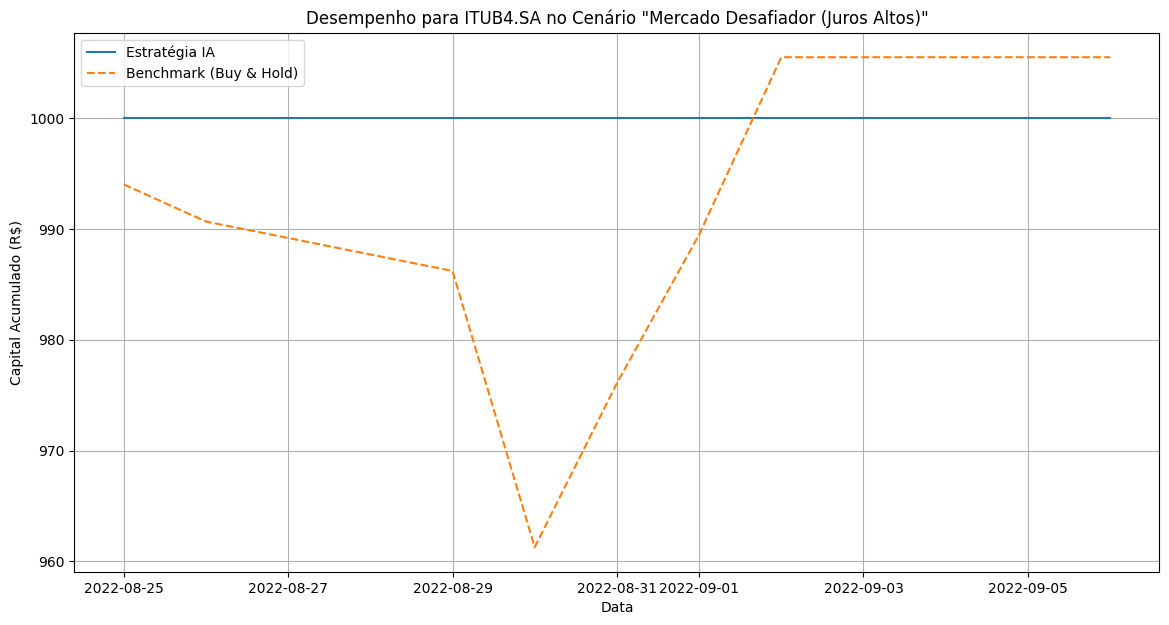

In [2]:
# ====================================================================
# CÓDIGO UNIFICADO E CORRIGIDO
# Sistema de backtesting para múltiplos ativos em múltiplos cenários.
# ====================================================================

# --- ETAPA 1: INSTALAÇÃO E IMPORTAÇÕES ---
!pip install yfinance pandas scikit-learn xgboost ta matplotlib --user

import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
import xgboost as xgb
import ta

# --- ETAPA 2: CONFIGURAÇÃO DOS ATIVOS (FATORES ESPECÍFICOS) ---
CONFIGURACAO_ATIVOS = {
    "VALE3.SA": {
        "setor": "Mineração (Global)",
        "fatores": ['SI=F', 'MCHI', 'BRL=X', 'CL=F'], 
        "nomes": ['Preco_Minerio_Ferro', 'ETF_China', 'Taxa_Cambio_USD_BRL', 'Preco_Petroleo']
    },
    "ITUB4.SA": {
        "setor": "Bancário (Nacional)",
        "fatores": ['^BVSP', 'EWZ', 'BRL=X'], 
        "nomes": ['Indice_Ibovespa', 'ETF_Brasil', 'Taxa_Cambio_USD_BRL']
    }
}

# --- ETAPA 3: DEFINIÇÃO DAS FUNÇÕES DO SISTEMA ---
def coletar_dados(ticker, fatores, nomes_fatores, start, end):
    print(f"--- Coletando dados para {ticker} de {start.date()} a {end.date()} ---")
    todos_tickers = list(set([ticker] + fatores))
    dados = yf.download(todos_tickers, start=start, end=end, progress=False, auto_adjust=True)
    if dados.empty or ticker not in dados['Close'].columns:
        print(f"Erro: Falha ao baixar dados para o ticker principal {ticker}.")
        return pd.DataFrame()
    
    df = pd.DataFrame(index=dados.index)
    df['Preco_Fechamento'] = dados['Close'][ticker]
    df['Volume'] = dados['Volume'][ticker]
    
    # <-- CORREÇÃO AQUI: Lógica simplificada para evitar o AttributeError
    for fator, nome in zip(fatores, nomes_fatores):
        if fator in dados['Close'].columns: 
            df[nome] = dados['Close'][fator]
        else: 
            print(f"Aviso: Não foi possível baixar o fator '{nome}' ({fator}).")
    return df

def engenharia_fatores(df):
    print("--- Realizando engenharia de fatores ---")
    df['Retorno_1d'] = df['Preco_Fechamento'].pct_change()
    df['Retorno_Futuro'] = df['Retorno_1d'].shift(-1)
    df['Momentum_5d'] = df['Preco_Fechamento'].pct_change(5)
    df['Volatilidade_10d'] = df['Retorno_1d'].rolling(window=10).std()
    df['RSI_14d'] = ta.momentum.RSIIndicator(close=df['Preco_Fechamento'], window=14).rsi()
    df['SMA_10_50_Ratio'] = ta.trend.SMAIndicator(df['Preco_Fechamento'], window=10).sma_indicator() / ta.trend.SMAIndicator(df['Preco_Fechamento'], window=50).sma_indicator()
    
    df.dropna(inplace=True)
    if df.empty:
        print("ERRO CRÍTICO: DataFrame ficou vazio após engenharia de fatores.")
        return df
        
    df['Target_Compra'] = (df['Retorno_Futuro'] > 0.002).astype(int)
    return df

def otimizar_modelo_xgb(df_treino, features, target):
    print("--- Otimizando hiperparâmetros do XGBoost... ---")
    X_treino = df_treino[features]
    y_treino = df_treino[target]
    if X_treino.empty: 
        print("ERRO: Conjunto de treino vazio.")
        return None, None

    scaler = StandardScaler()
    X_treino_scaled = scaler.fit_transform(X_treino)
    
    tscv = TimeSeriesSplit(n_splits=3)
    param_grid = {"max_depth": [3, 5], "n_estimators": [100, 200], "learning_rate": [0.05, 0.1]}
    xgb_model = xgb.XGBClassifier(objective='binary:logistic', use_label_encoder=False, verbosity=0, eval_metric='logloss', random_state=42)
    
    gsearch = GridSearchCV(xgb_model, param_grid, cv=tscv, scoring='accuracy', n_jobs=-1)
    gsearch.fit(X_treino_scaled, y_treino)
    
    print(f"Melhores parâmetros: {gsearch.best_params_}")
    return gsearch.best_estimator_, scaler

def otimizar_limiar(modelo, scaler, df_validacao, features):
    print("--- Otimizando o limiar de decisão... ---")
    X_validacao = df_validacao[features]
    if X_validacao.empty:
        print("ERRO: Conjunto de validação vazio.")
        return 0.5 # Retorna um valor padrão
        
    X_validacao_scaled = scaler.transform(X_validacao)
    probabilidades = modelo.predict_proba(X_validacao_scaled)[:, 1]
    
    melhor_lucro = -np.inf
    melhor_limiar = 0.5
    for limiar in np.arange(0.40, 0.61, 0.01):
        sinais = (probabilidades > limiar).astype(int)
        retorno_estrategia = df_validacao['Retorno_Futuro'] * sinais
        lucro_final = 1000 * (1 + retorno_estrategia).cumprod().iloc[-1] - 1000
        if lucro_final > melhor_lucro:
            melhor_lucro = lucro_final
            melhor_limiar = limiar
            
    print(f"Melhor limiar encontrado: {melhor_limiar:.2f}")
    return melhor_limiar

def executar_backtest(modelo, scaler, df_teste, features, limiar, ticker, cenario):
    print("--- Executando backtest final ---")
    if df_teste.empty:
        print("ERRO: Conjunto de teste vazio. Backtest cancelado.")
        return

    sinais = (modelo.predict_proba(scaler.transform(df_teste[features]))[:, 1] > limiar).astype(int)
    df_teste['Sinal_IA'] = sinais
    
    capital_inicial = 1000
    df_teste['Retorno_Estrategia'] = df_teste['Retorno_Futuro'] * df_teste['Sinal_IA']
    df_teste['Capital_Estrategia'] = capital_inicial * (1 + df_teste['Retorno_Estrategia']).cumprod()
    df_teste['Capital_Benchmark'] = capital_inicial * (1 + df_teste['Retorno_Futuro']).cumprod()
    
    lucro_ia = df_teste['Capital_Estrategia'].iloc[-1] - capital_inicial
    lucro_benchmark = df_teste['Capital_Benchmark'].iloc[-1] - capital_inicial
    
    print("\n" + "-"*40)
    print(f"RESULTADO FINAL: {ticker} | Cenário: {cenario}")
    print(f"Período de Teste: {df_teste.index.min().date()} a {df_teste.index.max().date()}")
    print(f"Lucro/Perda da Estratégia IA: R$ {lucro_ia:.2f}")
    print(f"Lucro/Perda do Benchmark (Buy & Hold): R$ {lucro_benchmark:.2f}")
    print("-"*40 + "\n")

    plt.figure(figsize=(14, 7))
    plt.plot(df_teste.index, df_teste['Capital_Estrategia'], label='Estratégia IA')
    plt.plot(df_teste.index, df_teste['Capital_Benchmark'], label='Benchmark (Buy & Hold)', linestyle='--')
    plt.title(f'Desempenho para {ticker} no Cenário "{cenario}"')
    plt.xlabel('Data')
    plt.ylabel('Capital Acumulado (R$)')
    plt.legend()
    plt.grid(True)
    nome_arquivo = f"resultado_{ticker}_{cenario.replace(' ', '_')}.png"
    plt.savefig(nome_arquivo)
    print(f"Gráfico salvo como '{nome_arquivo}'")
    plt.show()

# --- ETAPA 4: BLOCO DE EXECUÇÃO PRINCIPAL ---
if __name__ == '__main__':
    
    # --- PAINEL DE CONTROLE DE CENÁRIOS ---
    CENARIOS_DE_TESTE = {
        "Crise COVID-19": {
            "data_inicio_geral": datetime(2018, 1, 1),
            "data_fim_treino": datetime(2019, 12, 31),
            "data_fim_validacao": datetime(2020, 6, 30),
            "data_fim_teste": datetime(2020, 12, 31),
        },
        "Mercado de Alta Pós-Pandemia": {
            "data_inicio_geral": datetime(2019, 1, 1),
            "data_fim_treino": datetime(2020, 12, 31),
            "data_fim_validacao": datetime(2021, 6, 30),
            "data_fim_teste": datetime(2021, 12, 31),
        },
        "Mercado Desafiador (Juros Altos)": {
            "data_inicio_geral": datetime(2020, 1, 1),
            "data_fim_treino": datetime(2021, 12, 31),
            "data_fim_validacao": datetime(2022, 6, 30),
            "data_fim_teste": datetime(2022, 12, 31),
        },
    }

    LISTA_DE_ATIVOS = ['VALE3.SA', 'ITUB4.SA']
    
    # --- LAÇO DE REPETIÇÃO PARA EXECUTAR TODOS OS TESTES ---
    for cenario_nome, datas in CENARIOS_DE_TESTE.items():
        for ativo in LISTA_DE_ATIVOS:
            print("\n" + "="*80)
            print(f" EXECUTANDO CENÁRIO: '{cenario_nome}' PARA O ATIVO: {ativo} ".center(80, "="))
            print("="*80)

            config = CONFIGURACAO_ATIVOS[ativo]
            
            dados_brutos = coletar_dados(ativo, config['fatores'], config['nomes'], datas['data_inicio_geral'], datas['data_fim_teste'])
            df_completo = engenharia_fatores(dados_brutos)

            if df_completo.empty:
                print("Não foi possível continuar a análise para este ativo/cenário.")
                continue

            df_treino = df_completo.loc[:datas['data_fim_treino']]
            df_validacao = df_completo.loc[datas['data_fim_treino']:datas['data_fim_validacao']]
            df_teste = df_completo.loc[datas['data_fim_validacao']:]
            
            features = ['Momentum_5d', 'Volatilidade_10d', 'RSI_14d', 'SMA_10_50_Ratio', 'Volume'] + config['nomes']
            target = 'Target_Compra'
            
            modelo, scaler = otimizar_modelo_xgb(df_treino, features, target)
            
            if modelo:
                melhor_limiar = otimizar_limiar(modelo, scaler, df_validacao, features)
                executar_backtest(modelo, scaler, df_teste, features, melhor_limiar, ativo, cenario_nome)